<a href="https://colab.research.google.com/github/l3wandowskyy/Pricing-Footballers-Master/blob/main/preditict_value_footballer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Cleaning

In [162]:
import pandas as pd

# Import data
players = pd.read_excel('players_data_set.xlsx')

# Count rows and columns
players.shape

(7845, 30)

In [163]:
# Count the empty values in each column
players.isnull().sum()

,0
Player ID,0
Player Name,0
Nationality,0
Team Title,0
Team Position in League,0
Matches,0
League,0
UEFA league ranking,0
Position,0
Birth Date,0


In [164]:
# Delete empty values in Market Value and Goal Contribution Share
players = players.dropna(subset=['Market Value', 'Goal Contribution Share'])

In [165]:
# Fill in the blank values in the height and foot columns
players['Height'] = players['Height'].fillna(players['Height'].mean())
most_common_foot = players['Foot'].mode()[0]
players['Foot'] = players['Foot'].fillna(most_common_foot)

# Count the empty values in each column
players.isnull().sum()

,0
Player ID,0
Player Name,0
Nationality,0
Team Title,0
Team Position in League,0
Matches,0
League,0
UEFA league ranking,0
Position,0
Birth Date,0


In [166]:
# Check the data types of each column
players.dtypes

,0
Player ID,int64
Player Name,object
Nationality,object
Team Title,object
Team Position in League,object
Matches,int64
League,object
UEFA league ranking,int64
Position,object
Birth Date,object


In [167]:
# Change the data type for categorical columns
players["Nationality"] = players["Nationality"].astype("str")
players["Team Title"] = players["Team Title"].astype("str")
players["League"] = players["League"].astype("str")
players["Position"] = players["Position"].astype("str")
players["Foot"] = players["Foot"].astype("str")
players["Season"] = players["Season"].astype("str")

# Convert date columns to datetime format (dd.mm.yyyy)
players["Birth Date"] = pd.to_datetime(players["Birth Date"], format="%d.%m.%Y", errors="coerce")
players["Value Date"] = pd.to_datetime(players["Value Date"], errors="coerce")

# Extract numerical team position from string and convert to Int64
players["Team Position in League"] = players["Team Position in League"].str.extract("(\d+)").astype("Int64")

# Convert height column to Int64
players.loc[:, "Height"] = players["Height"].apply(lambda x: int(x) if pd.notna(x) else None).astype("Int64")

In [168]:
# Show duplicates
players[players.duplicated()]

,Player ID,Player Name,Nationality,Team Title,Team Position in League,Matches,League,UEFA league ranking,Position,Birth Date,...,Key Passes,Yellow Cards,Red Cards,npg,npxG,xGChain,xGBuildup,Season,Value Date,Market Value


In [169]:
# Rename columns
rename_dict = {
    "Matches": "Matches by Team (Season)",
    "Games": "Matches (Season)",
    "Time": "Minutes (Season)",
    "Goals": "Goals (Season)",
    "xG": "Expected Goals (Season)",
    "Assists": "Assists (Season)",
    "xA": "Expected Assists (Season)",
    "Shots": "Total Shots (Season)",
    "Key Passes": "Key Passes (Season)",
    "Yellow Cards": "Yellow Cards (Season)",
    "Red Cards": "Red Cards (Season)",
    "npg": "Non-Penalty Goals (Season)",
    "npxG": "Non-Penalty Expected Goals (Season)",
    "xGChain": "xG Chain (Season)",
    "xGBuildup": "xG Buildup (Season)"
}

players = players.rename(columns=rename_dict)

# Delete unnecessary columns
players = players.drop(columns=["Team Title", "League", "Value Date"])

# Show first columns
players.head()

,Player ID,Player Name,Nationality,Team Position in League,Matches by Team (Season),UEFA league ranking,Position,Birth Date,Height,Foot,...,Total Shots (Season),Key Passes (Season),Yellow Cards (Season),Red Cards (Season),Non-Penalty Goals (Season),Non-Penalty Expected Goals (Season),xG Chain (Season),xG Buildup (Season),Season,Market Value
0,532,Claudio Pizarro,Peru,18,34,4,CF,1978-10-03,184.0,right,...,16,7,0,0,1,1.863683,2.433829,1.129747,17/18,500000.0
1,532,Claudio Pizarro,Peru,8,34,4,CF,1978-10-03,184.0,right,...,25,10,1,0,5,2.712019,4.449489,1.552150,18/19,500000.0
2,532,Claudio Pizarro,Peru,16,34,3,CF,1978-10-03,184.0,right,...,4,5,0,0,0,0.433545,1.099479,0.333020,19/20,400000.0
3,1565,Alexander Meier,Germany,8,34,4,SS,1983-01-17,196.0,right,...,1,0,0,0,1,0.309795,0.444714,0.134919,17/18,750000.0
5,3306,Jonathan Walters,Ireland,7,38,2,RW,1983-09-20,183.0,right,...,1,0,0,0,0,0.179436,0.179436,0.000000,17/18,2000000.0


In [170]:
print(players.columns)

Index(['Player ID', 'Player Name', 'Nationality', 'Team Position in League',
       'Matches by Team (Season)', 'UEFA league ranking', 'Position',
       'Birth Date', 'Height', 'Foot', 'Matches (Season)', 'Minutes (Season)',
       'Goals (Season)', 'Goal Contribution Share', 'Expected Goals (Season)',
       'Assists (Season)', 'Expected Assists (Season)', 'Total Shots (Season)',
       'Key Passes (Season)', 'Yellow Cards (Season)', 'Red Cards (Season)',
       'Non-Penalty Goals (Season)', 'Non-Penalty Expected Goals (Season)',
       'xG Chain (Season)', 'xG Buildup (Season)', 'Season', 'Market Value'],
      dtype='object')


In [171]:
players.shape

(7700, 27)

In [172]:
# Calculate Q1 for Matches (Season) and Minutes (Season)
q1_matches = players["Matches (Season)"].quantile(0.25)
q1_minutes = players["Minutes (Season)"].quantile(0.25)

print(f"Q1 for Matches (Season): {q1_matches}")
print(f"Q1 for Minutes (Season): {q1_minutes}")

# Calculate how many players meet the condition for each separately
total_players = len(players)
players_above_q1_matches = len(players[players["Matches (Season)"] > q1_matches])
players_above_q1_minutes = len(players[players["Minutes (Season)"] > q1_minutes])
print(f"Total players: {total_players}")
print(f"Players with Matches (Season) above Q1: {players_above_q1_matches}")
print(f"Players with Minutes (Season) above Q1: {players_above_q1_minutes}")

Q1 for Matches (Season): 10.0
Q1 for Minutes (Season): 286.75
Total players: 7700
Players with Matches (Season) above Q1: 5647
Players with Minutes (Season) above Q1: 5775


In [173]:
# Filter players who played more matches and minutes than the first quartile (Q1)
players = players[(players["Matches (Season)"] > q1_matches) & (players["Minutes (Season)"] > q1_minutes)]
players.shape

(5494, 27)

In [174]:
# Convert summary statistics into per-match and per-90-minute rates
players["Match Participation Rate"] = players["Matches (Season)"] / players["Matches by Team (Season)"]
players["Minutes Participation Rate"] = players["Minutes (Season)"] / (players["Matches by Team (Season)"] * 90)

players["Goals per Match"] = players["Goals (Season)"] / players["Matches (Season)"]
players["Goals per 90 Minutes"] = (players["Goals (Season)"] / players["Minutes (Season)"]) * 90

players["Goal Contribution per Match"] = players["Goal Contribution Share"] / players["Matches (Season)"]
players["Goal Contribution per 90 Minutes"] = (players["Goal Contribution Share"] / players["Minutes (Season)"]) * 90

players["Expected Goals per Match"] = players["Expected Goals (Season)"] / players["Matches (Season)"]
players["Expected Goals per 90 Minutes"] = (players["Expected Goals (Season)"] / players["Minutes (Season)"]) * 90

players["Assists per Match"] = players["Assists (Season)"] / players["Matches (Season)"]
players["Assists per 90 Minutes"] = (players["Assists (Season)"] / players["Minutes (Season)"]) * 90

players["Expected Assists per Match"] = players["Expected Assists (Season)"] / players["Matches (Season)"]
players["Expected Assists per 90 Minutes"] = (players["Expected Assists (Season)"] / players["Minutes (Season)"]) * 90

players["Shots per Match"] = players["Total Shots (Season)"] / players["Matches (Season)"]
players["Shots per 90 Minutes"] = (players["Total Shots (Season)"] / players["Minutes (Season)"]) * 90

players["Key Passes per Match"] = players["Key Passes (Season)"] / players["Matches (Season)"]
players["Key Passes per 90 Minutes"] = (players["Key Passes (Season)"] / players["Minutes (Season)"]) * 90

players["Yellow Cards per Match"] = players["Yellow Cards (Season)"] / players["Matches (Season)"]
players["Yellow Cards per 90 Minutes"] = (players["Yellow Cards (Season)"] / players["Minutes (Season)"]) * 90

players["Red Cards per Match"] = players["Red Cards (Season)"] / players["Matches (Season)"]
players["Red Cards per 90 Minutes"] = (players["Red Cards (Season)"] / players["Minutes (Season)"]) * 90

players["Non-Penalty Goals per Match"] = players["Non-Penalty Goals (Season)"] / players["Matches (Season)"]
players["Non-Penalty Goals per 90 Minutes"] = (players["Non-Penalty Goals (Season)"] / players["Minutes (Season)"]) * 90

players["Non-Penalty Expected Goals per Match"] = players["Non-Penalty Expected Goals (Season)"] / players["Matches (Season)"]
players["Non-Penalty Expected Goals per 90 Minutes"] = (players["Non-Penalty Expected Goals (Season)"] / players["Minutes (Season)"]) * 90

players["xG Chain per Match"] = players["xG Chain (Season)"] / players["Matches (Season)"]
players["xG Chain per 90 Minutes"] = (players["xG Chain (Season)"] / players["Minutes (Season)"]) * 90

players["xG Buildup per Match"] = players["xG Buildup (Season)"] / players["Matches (Season)"]
players["xG Buildup per 90 Minutes"] = (players["xG Buildup (Season)"] / players["Minutes (Season)"]) * 90


# Drop summary columns
players.drop(columns=[
    'Matches by Team (Season)', 'Matches (Season)', 'Minutes (Season)', 'Goals (Season)',
    'Goal Contribution Share', 'Expected Goals (Season)', 'Assists (Season)',
    'Expected Assists (Season)', 'Total Shots (Season)', 'Key Passes (Season)',
    'Yellow Cards (Season)', 'Red Cards (Season)', 'Non-Penalty Goals (Season)',
    'Non-Penalty Expected Goals (Season)', 'xG Chain (Season)', 'xG Buildup (Season)'
], inplace=True)

<ipython-input-174-0dc89735b276>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players["Match Participation Rate"] = players["Matches (Season)"] / players["Matches by Team (Season)"]
<ipython-input-174-0dc89735b276>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players["Minutes Participation Rate"] = players["Minutes (Season)"] / (players["Matches by Team (Season)"] * 90)
<ipython-input-174-0dc89735b276>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [175]:
players.head()

,Player ID,Player Name,Nationality,Team Position in League,UEFA league ranking,Position,Birth Date,Height,Foot,Season,...,Red Cards per Match,Red Cards per 90 Minutes,Non-Penalty Goals per Match,Non-Penalty Goals per 90 Minutes,Non-Penalty Expected Goals per Match,Non-Penalty Expected Goals per 90 Minutes,xG Chain per Match,xG Chain per 90 Minutes,xG Buildup per Match,xG Buildup per 90 Minutes
0,532,Claudio Pizarro,Peru,18,4,CF,1978-10-03,184.0,right,17/18,...,0.000000,0.000000,0.062500,0.157895,0.116480,0.294266,0.152114,0.384289,0.070609,0.178381
1,532,Claudio Pizarro,Peru,8,4,CF,1978-10-03,184.0,right,18/19,...,0.000000,0.000000,0.192308,0.684932,0.104308,0.371509,0.171134,0.609519,0.059698,0.212623
6,3332,Wayne Rooney,England,8,2,CF,1985-10-24,176.0,right,17/18,...,0.000000,0.000000,0.225806,0.273794,0.139949,0.169691,0.269874,0.327226,0.144046,0.174658
7,3333,James Milner,England,4,2,CM,1986-01-04,175.0,right,17/18,...,0.000000,0.000000,0.000000,0.000000,0.035681,0.059263,0.319457,0.530585,0.259321,0.430706
8,3333,James Milner,England,2,2,CM,1986-01-04,175.0,right,18/19,...,0.032258,0.050704,0.064516,0.101408,0.034609,0.054399,0.402824,0.633172,0.316379,0.497295


In [176]:
print(players.columns)

Index(['Player ID', 'Player Name', 'Nationality', 'Team Position in League',
       'UEFA league ranking', 'Position', 'Birth Date', 'Height', 'Foot',
       'Season', 'Market Value', 'Match Participation Rate',
       'Minutes Participation Rate', 'Goals per Match', 'Goals per 90 Minutes',
       'Goal Contribution per Match', 'Goal Contribution per 90 Minutes',
       'Expected Goals per Match', 'Expected Goals per 90 Minutes',
       'Assists per Match', 'Assists per 90 Minutes',
       'Expected Assists per Match', 'Expected Assists per 90 Minutes',
       'Shots per Match', 'Shots per 90 Minutes', 'Key Passes per Match',
       'Key Passes per 90 Minutes', 'Yellow Cards per Match',
       'Yellow Cards per 90 Minutes', 'Red Cards per Match',
       'Red Cards per 90 Minutes', 'Non-Penalty Goals per Match',
       'Non-Penalty Goals per 90 Minutes',
       'Non-Penalty Expected Goals per Match',
       'Non-Penalty Expected Goals per 90 Minutes', 'xG Chain per Match',
       'xG Ch

In [177]:
# Calculate age of player
def calculate_age_player(players):

    players['Birth Date'] = pd.to_datetime(players['Birth Date'], errors='coerce')

    season_dict = {'17/18': 2018, '18/19': 2019, '19/20': 2020, '20/21': 2021, '21/22': 2022, '22/23': 2023}

    players['Season'] = players['Season'].astype(str)
    players['End of Season'] = players['Season'].map(season_dict)

    players['Age'] = players['End of Season'] - players['Birth Date'].dt.year

    players.drop(columns=['End of Season', 'Birth Date'], inplace=True)

    return players

players = calculate_age_player(players)
players.head()

<ipython-input-177-bd409139d6a4>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players['Birth Date'] = pd.to_datetime(players['Birth Date'], errors='coerce')
<ipython-input-177-bd409139d6a4>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players['Season'] = players['Season'].astype(str)
<ipython-input-177-bd409139d6a4>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

,Player ID,Player Name,Nationality,Team Position in League,UEFA league ranking,Position,Height,Foot,Season,Market Value,...,Red Cards per 90 Minutes,Non-Penalty Goals per Match,Non-Penalty Goals per 90 Minutes,Non-Penalty Expected Goals per Match,Non-Penalty Expected Goals per 90 Minutes,xG Chain per Match,xG Chain per 90 Minutes,xG Buildup per Match,xG Buildup per 90 Minutes,Age
0,532,Claudio Pizarro,Peru,18,4,CF,184.0,right,17/18,500000.0,...,0.000000,0.062500,0.157895,0.116480,0.294266,0.152114,0.384289,0.070609,0.178381,40.0
1,532,Claudio Pizarro,Peru,8,4,CF,184.0,right,18/19,500000.0,...,0.000000,0.192308,0.684932,0.104308,0.371509,0.171134,0.609519,0.059698,0.212623,41.0
6,3332,Wayne Rooney,England,8,2,CF,176.0,right,17/18,10000000.0,...,0.000000,0.225806,0.273794,0.139949,0.169691,0.269874,0.327226,0.144046,0.174658,33.0
7,3333,James Milner,England,4,2,CM,175.0,right,17/18,15000000.0,...,0.000000,0.000000,0.000000,0.035681,0.059263,0.319457,0.530585,0.259321,0.430706,32.0
8,3333,James Milner,England,2,2,CM,175.0,right,18/19,15000000.0,...,0.050704,0.064516,0.101408,0.034609,0.054399,0.402824,0.633172,0.316379,0.497295,33.0


In [178]:
# New column order
new_column_order = [
    "Player ID", "Player Name", "Age", "Height", "Foot", "Nationality", "Position",
    "Team Position in League", "UEFA league ranking", "Season", "Match Participation Rate",
    "Minutes Participation Rate", "Goals per Match", "Goals per 90 Minutes",
    "Goal Contribution per Match", "Goal Contribution per 90 Minutes",
    "Expected Goals per Match", "Expected Goals per 90 Minutes",
    "Assists per Match", "Assists per 90 Minutes",
    "Expected Assists per Match", "Expected Assists per 90 Minutes",
    "Shots per Match", "Shots per 90 Minutes", "Key Passes per Match",
    "Key Passes per 90 Minutes", "Yellow Cards per Match", "Yellow Cards per 90 Minutes",
    "Red Cards per Match", "Red Cards per 90 Minutes", "Non-Penalty Goals per Match",
    "Non-Penalty Goals per 90 Minutes", "Non-Penalty Expected Goals per Match",
    "Non-Penalty Expected Goals per 90 Minutes", "xG Chain per Match",
    "xG Chain per 90 Minutes", "xG Buildup per Match", "xG Buildup per 90 Minutes",
    "Market Value"
]

players = players[new_column_order]
players.head()

,Player ID,Player Name,Age,Height,Foot,Nationality,Position,Team Position in League,UEFA league ranking,Season,...,Red Cards per 90 Minutes,Non-Penalty Goals per Match,Non-Penalty Goals per 90 Minutes,Non-Penalty Expected Goals per Match,Non-Penalty Expected Goals per 90 Minutes,xG Chain per Match,xG Chain per 90 Minutes,xG Buildup per Match,xG Buildup per 90 Minutes,Market Value
0,532,Claudio Pizarro,40.0,184.0,right,Peru,CF,18,4,17/18,...,0.000000,0.062500,0.157895,0.116480,0.294266,0.152114,0.384289,0.070609,0.178381,500000.0
1,532,Claudio Pizarro,41.0,184.0,right,Peru,CF,8,4,18/19,...,0.000000,0.192308,0.684932,0.104308,0.371509,0.171134,0.609519,0.059698,0.212623,500000.0
6,3332,Wayne Rooney,33.0,176.0,right,England,CF,8,2,17/18,...,0.000000,0.225806,0.273794,0.139949,0.169691,0.269874,0.327226,0.144046,0.174658,10000000.0
7,3333,James Milner,32.0,175.0,right,England,CM,4,2,17/18,...,0.000000,0.000000,0.000000,0.035681,0.059263,0.319457,0.530585,0.259321,0.430706,15000000.0
8,3333,James Milner,33.0,175.0,right,England,CM,2,2,18/19,...,0.050704,0.064516,0.101408,0.034609,0.054399,0.402824,0.633172,0.316379,0.497295,15000000.0


## EDA - Exploratory Data Analysis

In [179]:
# List the number of unique nationalities
nationality_counts = players["Nationality"].value_counts()
print(nationality_counts)

# Number of records for each nationality
nationality_counts = players["Nationality"].value_counts()
print(nationality_counts)

Nationality
Spain                       736
France                      642
Italy                       468
Germany                     416
England                     357
                           ... 
Guatemala                     1
Central African Republic      1
Georgia                       1
Libya                         1
Cuba                          1
Name: count, Length: 115, dtype: int64
Nationality
Spain                       736
France                      642
Italy                       468
Germany                     416
England                     357
                           ... 
Guatemala                     1
Central African Republic      1
Georgia                       1
Libya                         1
Cuba                          1
Name: count, Length: 115, dtype: int64


In [180]:
# Q1 for nationalities
q1_nationality = nationality_counts.quantile(0.25)
print(f"Q1 for nationalities: {q1_nationality}")

# List nationalities below the Q1
low_nationality_counts = nationality_counts[nationality_counts <= q1_nationality]
print(low_nationality_counts)

Q1 for nationalities: 5.0
Nationality
Mauritania                  5
Syria                       5
Equatorial Guinea           5
Suriname                    5
Iran                        5
Curacao                     4
Philippines                 4
Moldova                     4
Zambia                      4
Montenegro                  4
Chad                        4
Uzbekistan                  3
China                       3
Grenada                     2
Cyprus                      2
Bulgaria                    2
Sierra Leone                2
Martinique                  2
Costa Rica                  2
Kenya                       1
Trinidad and Tobago         1
St. Kitts & Nevis           1
Madagascar                  1
Tanzania                    1
Congo                       1
Haiti                       1
Laos                        1
Burundi                     1
Guatemala                   1
Central African Republic    1
Georgia                     1
Libya                       1
Cu

In [181]:
# Create a list of nationalities to convert to “Other”
low_representation_nations = players["Nationality"].value_counts()[players["Nationality"].value_counts() <= q1_nationality].index
players["Nationality"] = players["Nationality"].replace(low_representation_nations, "Other")

# List the number of unique nationalities
nationality_unique = players["Nationality"].unique().tolist()
print(nationality_unique)

# Number of records for each nationality
print(players["Nationality"].value_counts(dropna=False))

['Peru', 'England', 'Sweden', 'Scotland', 'Netherlands', 'Germany', 'Senegal', 'France', 'Tunisia', 'Italy', 'Spain', "Cote d'Ivoire", 'Portugal', 'Czech Republic', 'Switzerland', 'Argentina', 'North Macedonia', 'Paraguay', 'Ghana', 'Denmark', 'Norway', 'Belgium', 'Brazil', 'Mexico', 'Bosnia-Herzegovina', 'Iceland', 'Slovenia', 'Croatia', 'Northern Ireland', 'Austria', 'United States', 'both', 'Greece', 'Türkiye', 'Ireland', 'Serbia', 'Togo', 'Benin', 'Finland', 'Chile', 'Ecuador', 'Morocco', 'Poland', 'Slovakia', 'Hungary', 'Colombia', 'Wales', 'Uruguay', 'Israel', 'Nigeria', 'Cameroon', 'Other', 'Mali', 'Guinea', 'DR Congo', 'Russia', 'Canada', 'Armenia', 'Guadeloupe', 'Gabon', 'Ukraine', 'Burkina Faso', 'Algeria', 'Japan', 'Venezuela', 'Korea, South', 'Korea', 'Romania', 'Jamaica', 'New Zealand', 'Australia', 'Honduras', 'Albania', 'Kosovo', 'Egypt', 'Angola', 'Cape Verde', 'South Africa', 'Luxembourg', 'Guinea-Bissau', 'Comoros', 'Zimbabwe', 'The Gambia']
Nationality
Spain         

In [182]:
# Convert incorrect value of “both” to “Other”
players["Nationality"] = players["Nationality"].replace("both", "Other")

# Check the corrected values
print(players["Nationality"].value_counts().sort_values(ascending=True))

Nationality
Northern Ireland      6
New Zealand           6
Luxembourg            6
Ecuador               6
Honduras              6
                   ... 
England             357
Germany             416
Italy               468
France              642
Spain               736
Name: count, Length: 82, dtype: int64


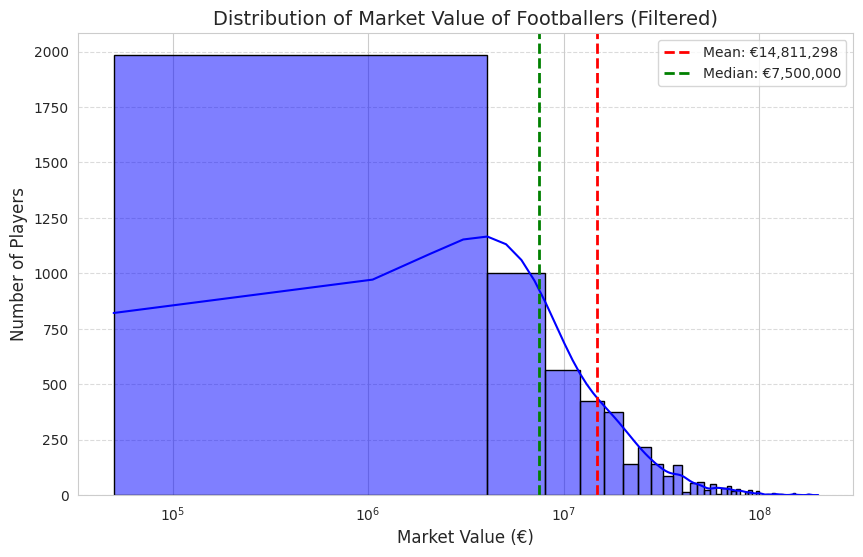

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate mean and median
mean_value = players["Market Value"].mean()
median_value = players["Market Value"].median()

# Set up the chart
plt.figure(figsize=(10, 6))
sns.histplot(players["Market Value"], bins=50, kde=True, color="blue", edgecolor="black")

# Add the mean and median lines
plt.axvline(mean_value, color="red", linestyle="dashed", linewidth=2, label=f"Mean: €{int(mean_value):,}")
plt.axvline(median_value, color="green", linestyle="dashed", linewidth=2, label=f"Median: €{int(median_value):,}")

# Logaritmic scale
plt.xscale("log")

# Axis descriptions and title
plt.xlabel("Market Value (€)", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)
plt.title("Distribution of Market Value of Footballers (Filtered)", fontsize=14)

# Grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Show the chart
plt.show()